In [1]:
import sys
import torch

sys.path.append('/app/dev')
from models.speechlms.qwen2_audio.qwen2_audio import Qwen2AudioKVOpt
from utils import clean_gpu_cache
from plot import plot_relevance, plot_attn_maps

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device_num=0
clean_gpu_cache(device_num=device_num)

device = f'cuda:{device_num}' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
qwen2audioKVOpt = Qwen2AudioKVOpt(verbose=True).to(device, dtype=torch.bfloat16)

[GPU 0] allocated: 0.000 GB
[GPU 0] reserved : 0.000 GB
Device: cuda:0


Sliding Window Attention is enabled but not implemented for `eager`; unexpected results may be encountered.


Applying Qwen2AttentionKVOpt on the language model's self attention...
Applied on layer 0
Applied on layer 1
Applied on layer 2
Applied on layer 3
Applied on layer 4
Applied on layer 5
Applied on layer 6
Applied on layer 7
Applied on layer 8
Applied on layer 9
Applied on layer 10
Applied on layer 11
Applied on layer 12
Applied on layer 13
Applied on layer 14
Applied on layer 15
Applied on layer 16
Applied on layer 17
Applied on layer 18
Applied on layer 19
Applied on layer 20
Applied on layer 21
Applied on layer 22
Applied on layer 23
Applied on layer 24
Applied on layer 25
Applied on layer 26
Applied on layer 27
Applied on layer 28
Applied on layer 29
Applied on layer 30
Applied on layer 31


Loading checkpoint shards: 100%|██████████| 5/5 [00:01<00:00,  2.55it/s]
Some weights of Qwen2AudioForConditionalGenerationKVOpt were not initialized from the model checkpoint at Qwen/Qwen2-Audio-7B-Instruct and are newly initialized: ['reference_model.lm_head.weight', 'reference_model.model.embed_tokens.weight', 'reference_model.model.layers.0.input_layernorm.weight', 'reference_model.model.layers.0.mlp.down_proj.weight', 'reference_model.model.layers.0.mlp.gate_proj.weight', 'reference_model.model.layers.0.mlp.up_proj.weight', 'reference_model.model.layers.0.post_attention_layernorm.weight', 'reference_model.model.layers.0.self_attn.k_proj.bias', 'reference_model.model.layers.0.self_attn.k_proj.weight', 'reference_model.model.layers.0.self_attn.o_proj.weight', 'reference_model.model.layers.0.self_attn.q_proj.bias', 'reference_model.model.layers.0.self_attn.q_proj.weight', 'reference_model.model.layers.0.self_attn.v_proj.bias', 'reference_model.model.layers.0.self_attn.v_proj.weight',

Patched models.speechlms.qwen2_audio.modeling_qwen2_audio_kv_opt
Patched Qwen2MLP
Patched Qwen2RMSNorm


In [14]:
wav_instruct_dict = {
    'water': {'wav': '/app/datasets/air_bench/Foundation/Sound_AQA_clothoaqa/river_mouth3.wav', 'instruction': 'How many times exactly does the water splash?'}, # worked with alpha=1 layers 1-27
    'cat_meowing': {'wav': '/app/datasets/air_bench/Foundation/Audio_Grounding_AudioGrounding/Y_GI7meqlYZk.flac', 'instruction': 'How many dog barks there are in the audio?'}, # worked with alpha=1 layers 1-27
    'transcribe': {'wav': '/app/datasets/librispeech/test-clean/237/126133/237-126133-0003.wav', 'instruction': 'Transcribe the audio. Output only the raw transcription, no commentary.'},
    'gunshot': {'wav': '/app/datasets/air_bench/Foundation/Sound_AQA_avqa/3049.flac', 'instruction': "how many gun shots there are in the audio?"},
    'police': {'wav': '/app/datasets/air_bench/Foundation/Sound_AQA_avqa/3593.flac', 'instruction': "What are the police officers saying?"},

    # /app/datasets/air_bench/Foundation/Sound_AQA_avqa/3511.flac # water steam
    'song': {'wav': '/app/datasets/air_bench/Foundation/vocal_sound_classification_VocalSound/f1254_0_sigh.wav', 'instruction': "What is the genere of the song in the audio?"},
    

    # 'scared': {'wav': '/app/datasets/CORAAL/test/PRV_se0_ag1_m_02_1_1475586_1480369.wav', 'instruction': 'Does the speaker sound scared?'}, # worked with alpha=1 layers 1-27
    # 'funny': {'wav': '/app/datasets/librispeech/dev-clean/1272/135031/1272-135031-0019.wav', 'instruction': "Does the speaker sound genuinely amused, ironic, neutral, or serious?"},
    # 'fear': {'wav': '/app/datasets/librispeech/train-clean-360/820/123135/820-123135-0033.wav', 'instruction': "Does the speaker himself sound fearful?"},
    
}

task = 'song'

inputs = qwen2audioKVOpt.get_inputs_for_forward(
            instruction=wav_instruct_dict[task]['instruction'],
            wav_path=wav_instruct_dict[task]['wav'],
            device_num=device_num
        )

In [ ]:
# import librosa
# MAX_AUDIO_DURATION = 1

# def temp_input(qwen2audioKVOpt, instruction, wav_path, device):
#     sr = qwen2audioKVOpt.processor.feature_extractor.sampling_rate
#     audio_array, _ = librosa.load(wav_path, sr=sr)

#     # trim audio to 30 sec - audio encoder limit
#     if len(audio_array) > MAX_AUDIO_DURATION*sr:
#         audio_array = audio_array[:MAX_AUDIO_DURATION*sr]

#     # create conversation with proper audio token format
#     conversation = [
#         {'role': 'system', 'content': 'You are a helpful assistant.'}, 
#         {"role": "user", "content": [
#             {"type": "audio", "audio": audio_array},
#             {"type": "text", "text": instruction},
#         ]},
#     ]

#     prmopt = qwen2audioKVOpt.processor.apply_chat_template(conversation, add_generation_prompt=True, tokenize=False)
#     inputs_new = qwen2audioKVOpt.processor(text=prmopt, audio=[audio_array], sampling_rate=sr, return_tensors="pt", padding=True)
#     inputs_new = {k: v.to(device) if hasattr(v, 'to') else v for k, v in inputs_new.items()}

#     return inputs_new

# inputs_new = temp_input(qwen2audioKVOpt, wav_instruct_dict[task]['instruction'], wav_instruct_dict[task]['wav'], device)

In [15]:
print(wav_instruct_dict[task]['instruction'])
hyper_params = {
    'opt_steps': 7,
    'opt_lr': 0.00007,#0.0002,
    'lambda_kl': 0.01, #0.05,
    'lambda_relevance_multimodal': 1,
    'lambda_relevance_text': 1.0,
}
approach='opt'

deltas_layers = list(range(0,32))

clean_gpu_cache(device_num=device_num)

response, relevances, attentions = qwen2audioKVOpt.generate(
    **hyper_params,
    inputs=inputs,
    # inputs=inputs_new,
    approach=approach,
    deltas_layers=deltas_layers,
    max_new_tokens=30,
    plot=True
)

What is the genere of the song in the audio?
[GPU 0] allocated: 30.796 GB
[GPU 0] reserved : 31.637 GB
modality_bos_idx: 19 | audio_eos_idx: 142

---------------------
Generation step: 0
Adam step: 0
student forward...
reference forward...
KL: 0.0008 | Audio Relevance: -6.7812 | Overall loss: 6.7812
Adam step: 1
student forward...
KL: 0.0031 | Audio Relevance: -6.7812 | Overall loss: 6.7812
Adam step: 2
student forward...
KL: 0.0015 | Audio Relevance: -6.7812 | Overall loss: 6.7812
Adam step: 3
student forward...
KL: 0.0035 | Audio Relevance: -6.7812 | Overall loss: 6.7812
Adam step: 4
student forward...
KL: 0.0034 | Audio Relevance: -6.8438 | Overall loss: 6.8438
Adam step: 5
student forward...
KL: 0.0032 | Audio Relevance: -6.9062 | Overall loss: 6.9062
Adam step: 6
student forward...
KL: 0.0027 | Audio Relevance: -6.9688 | Overall loss: 6.9688
Partial answer: The
---------------------

---------------------
Generation step: 1
Adam step: 0
student forward...
reference forward...
KL: 

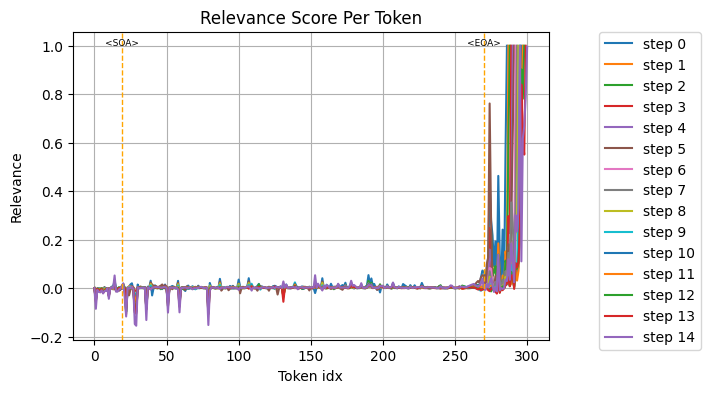

In [ ]:
# plots

audio_start = 19
audio_end = 270
step=None

plot_relevance(
    relevances=relevances,
    modality_start=audio_start,
    modality_end=audio_end,
    example=f'qwen2audio/{task}',
    target_step=step # None for plotting all the steps
)

# plot_attn_maps(
#     attentions=attentions,
#     target_step=step,
#     layers=[0,5,17,31],
#     modality_start=audio_start,
#     modality_end=audio_end,
#     example=f'qwen2audio/{task}',    
# )

In [ ]:
wav_instruct_dict = {
    'water': {'wav': '/app/datasets/air_bench/Foundation/Sound_AQA_clothoaqa/river_mouth3.wav', 'instruction': 'How many times exactly does the water splash'}, # worked with alpha=1 layers 1-27
    'scared': {'wav': '/app/datasets/CORAAL/test/PRV_se0_ag1_m_02_1_1475586_1480369.wav', 'instruction': 'Is the speaker sound scared?'}, # worked with alpha=1 layers 1-27
    'cat_meowing': {'wav': '/app/datasets/air_bench/Foundation/Audio_Grounding_AudioGrounding/Y_GI7meqlYZk.flac', 'instruction': 'How many dog barks there are in the audio?'}, # worked with alpha=1 layers 1-27
}
general_knowledge_instruction= 'Whats is the capital city of france?. Output only the raw city name, no commentary.'
transcribe_instruction = 'Transcribe the audio. Output only the raw transcription, no commentary.'
describe_instruction4 = 'Describe the audio in details'

plot = True
device= 'cpu'